In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ml_library import KNN , train_test_split , z_score_normalization

In [2]:
df = pd.read_csv('./dataset/train_multi_class.csv')

df.shape

(50001, 41)

In [3]:
df.sample(5)

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_31,feature_32,feature_33,feature_34,feature_35,feature_36,feature_37,feature_38,feature_39,target
34118,33.267549,30.688544,45.068752,30.944306,36.443917,29.461657,13.388090,17.289354,1022.614577,944.524570,...,58.713966,17.236668,32.413064,90.858438,5701.993864,0.000391,210.278308,12.666233,1.026381,4.0
5279,15.408917,21.758932,17.962738,26.300095,40.491547,37.276191,47.974061,43.216931,1018.233089,1107.104871,...,39.290844,75.733036,7.792872,36.002765,5409.447125,-0.000333,174.900232,6.696886,0.942919,1.0
23393,27.540068,29.961404,40.042607,32.768087,32.857132,38.529629,19.132459,23.029181,1094.943243,961.572895,...,43.753055,26.576746,-2.092769,84.848001,5464.883255,-0.000114,162.110641,-2.364703,0.986077,2.0
38541,40.712716,14.892005,45.270600,45.917204,33.969881,16.424092,42.851573,16.943181,1037.455000,1108.369086,...,70.634984,95.916342,64.099992,42.348638,4908.906323,0.000235,210.408368,-1.007506,1.039927,0.0
21164,18.168897,40.532876,18.925729,18.975290,11.488745,45.608622,14.293728,41.820263,944.671331,972.277998,...,57.364264,65.818083,75.757992,78.424991,5450.230872,-0.000143,197.354947,0.762025,1.065609,4.0


In [4]:
np.unique(df['target'])


array([ 0.,  1.,  2.,  3.,  4., nan])

In [5]:
df[df.isnull().any(axis=1)]

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_31,feature_32,feature_33,feature_34,feature_35,feature_36,feature_37,feature_38,feature_39,target
22,4.292400e+01,26.506754,43.204687,42.894000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23,8.745119e+10,24.797890,15.920502,30.969993,18.504258,1034.313996,1026.832264,1082.53978,1005.892134,927.434537,...,92.754777,4788.13373,-0.000435,198.056171,6.818516,1.004131,0.0,NaN,NaN,NaN


In [6]:
df = df.dropna()
df.shape

(49999, 41)

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
X = df.drop('target', axis=1).values
y = df['target'].values

X.shape , y.shape

((49999, 40), (49999,))

In [9]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.2)

X_train = z_score_normalization(X_train)
X_test = z_score_normalization(X_test)

X_train.shape , X_test.shape , y_train.shape , y_test.shape

((40000, 40), (9999, 40), (40000,), (9999,))

In [10]:
model = KNN(k= 2)

model.fit(X_train , y_train)

In [11]:
y_pred = model.predict(X_test)
y_pred

array([3., 0., 1., ..., 3., 0., 4.], shape=(9999,))

In [12]:
y_test

array([1., 2., 1., ..., 3., 0., 4.], shape=(9999,))

Accuracy: 0.6344634463446345
Precision: 0.9334298118668596
Recall: 0.8698583951449764
F1 Score: 0.9005235602094241
Confusion Matrix:
[[2434   92]
 [ 193 1290]]


(np.float64(0.6344634463446345),
 np.float64(0.9334298118668596),
 np.float64(0.8698583951449764),
 np.float64(0.9005235602094241),
 array([[2434,   92],
        [ 193, 1290]]))

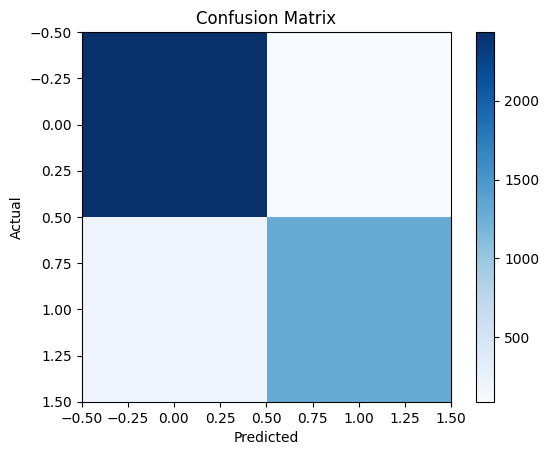

In [13]:
model.evaluation_metrics(y_test, y_pred)

In [14]:
df_testing = pd.read_csv('./dataset/test_multi_class.csv')

df_testing

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_30,feature_31,feature_32,feature_33,feature_34,feature_35,feature_36,feature_37,feature_38,feature_39
0,42.286055,31.779281,27.402748,23.579298,13.845149,29.264550,15.266200,33.992584,1016.098325,986.743680,...,61.413228,71.113622,73.887272,117.349712,88.154989,4778.394029,0.000436,193.807630,-9.164982,0.958566
1,34.702777,40.921095,22.668565,24.601244,23.070756,28.276820,27.124227,23.425675,976.526548,927.317616,...,66.705982,46.310436,62.339148,87.828162,102.732089,5286.313312,0.000077,218.859389,7.090382,0.967146
2,17.705340,29.161218,13.063318,22.058983,35.712598,40.643941,32.664167,37.832438,1066.881745,1047.491958,...,64.219495,60.852407,46.783325,-5.328927,5.672618,5138.381508,-0.000491,160.820235,-4.845227,1.040194
3,24.717636,18.038756,14.995183,33.880904,38.376973,28.854553,45.356190,41.124285,973.289768,1050.713288,...,67.283952,43.300611,66.724295,3.693005,16.538044,4936.941331,-0.000782,183.358710,-1.647154,0.904313
4,21.544868,21.768141,10.727728,32.310743,35.611273,32.796327,43.815551,46.677691,1004.452411,1098.917452,...,67.932385,51.494936,97.280299,14.692947,21.021194,5016.612762,-0.000745,189.399012,-6.649322,1.002220
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,36.697562,15.124782,42.668607,43.425432,40.856664,25.906990,46.978633,28.901576,1064.719477,1074.290806,...,52.883944,65.720791,31.041298,4.309660,24.903742,4315.920684,0.000300,176.812060,0.385002,1.020256
24996,43.733958,29.743271,45.826813,23.250658,22.324706,34.548851,16.203391,16.732798,1013.005153,993.742122,...,41.240748,72.365144,17.298680,81.479108,80.352414,4885.528079,-0.000018,183.851250,0.324598,1.021930
24997,23.087749,25.025565,23.822503,29.877265,24.640519,33.950847,40.970616,38.230391,1042.344616,1065.543185,...,58.702563,39.482295,74.100190,18.509173,9.134551,4884.726726,-0.000057,173.859379,-3.742330,1.079811
24998,16.128278,33.650378,19.581564,18.541185,18.208629,49.290109,36.753738,41.975141,998.651472,1069.332255,...,61.501710,57.012554,86.238592,30.886995,1.705793,4937.136508,-0.000928,154.498272,-2.258004,1.039782


In [15]:
df_testing[df_testing.isnull().any(axis=1)]

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_30,feature_31,feature_32,feature_33,feature_34,feature_35,feature_36,feature_37,feature_38,feature_39


In [16]:
X_testing = df_testing.copy().values
X_testing = z_score_normalization(X_testing)
X_testing.shape

(25000, 40)

In [17]:
y_pred_test = model.predict(X_testing)

y_pred_test

array([0., 3., 1., ..., 3., 1., 4.], shape=(25000,))

In [18]:
df_testing['target'] = y_pred_test
df_testing.to_csv('./output/knn_multi_class.csv' , index = False)